# Implementation of a Deep Asset Liability Management Environment

In [16]:
import os
import sys
import numpy as np
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))

from environment.config import markov_config
from environment.bond import Bond
from environment.env import DeepALMEnv
from models.utils import print_bond_universe, plot_learning_curve, plot_final_wealth
from models.source.sac import evaluate_sac_agent, evaluate_sac_alm
from models.DirichletPolicy import DirichletSACPolicy

In [17]:
TRAINING = True
DIRICHLET = False
# Create logging directory
if DIRICHLET:
    log_dir = "tmp_log/SAC10/Dirichlet"
    os.makedirs(log_dir, exist_ok=True)
else:
    log_dir = "tmp_log/SAC10/Gaussian"
    os.makedirs(log_dir, exist_ok=True)

## Gym Wrapper for SB3 compatibility

In [18]:
# Create and display bond universe
bonds = [Bond(**cfg) for cfg in markov_config["bond_configs"]]
K = len(bonds)
print_bond_universe(bonds)

# Initialize Training Environment
env = DummyVecEnv([lambda: Monitor(
    DeepALMEnv(markov_config=markov_config, seed=9, use_dirichlet=DIRICHLET), 
    filename=os.path.join(log_dir, "monitor.csv"), 
    info_keywords=('nav',)
)])

-----------------------------------------------
| Bond Type            | Maturity (Months)    |
-----------------------------------------------
| 1M_Bill              | 1                    |
| 3M_ZeroCoupon        | 3                    |
| 6M_ZeroCoupon        | 6                    |
| 12M_6Months          | 12                   |
| 24M_6Months          | 24                   |
-----------------------------------------------


In [19]:
# Model declaration with hyperparameters
model = SAC(
    policy=DirichletSACPolicy if DIRICHLET else "MultiInputPolicy",
    env=env,
    learning_rate=1.1031939831959191e-05,
    buffer_size=100_000,
    batch_size=256,
    gamma=1.0,
    tau=0.005,
    train_freq=1,
    gradient_steps=1,
    ent_coef="auto",
    verbose=1,
    device="auto"
)



Using cpu device


In [ ]:
if TRAINING:
    print("Starting SAC Training...")
    model.learn(total_timesteps=600_000, log_interval=10)
    print("Training Completed.")
    model.save("saved_models/sacdp.zip")
else:
    print("Loading pre-trained model...")
    model = SAC.load("saved_models/sacdp.zip")

Starting SAC Training...
Training Completed.


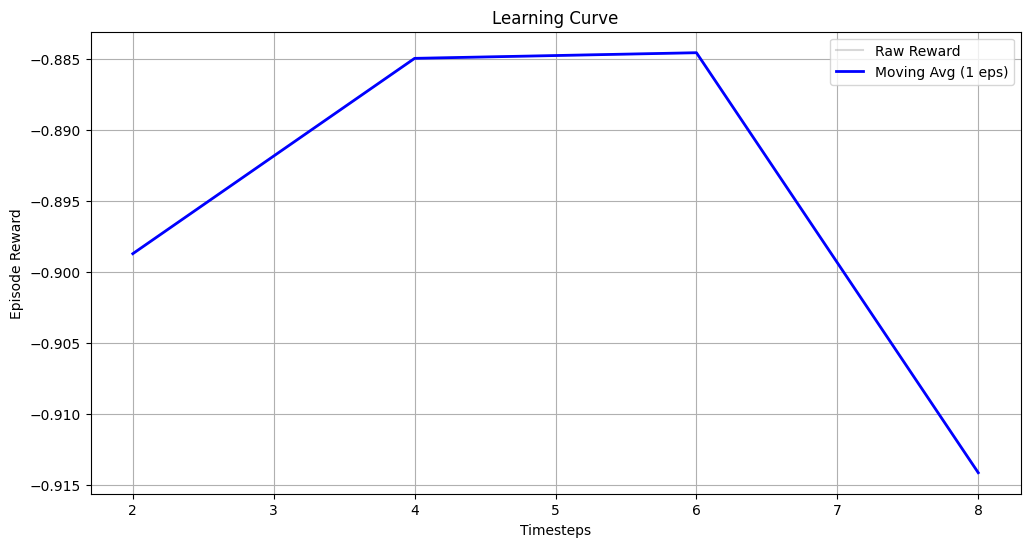

In [21]:
if TRAINING:
    plot_learning_curve(log_dir)

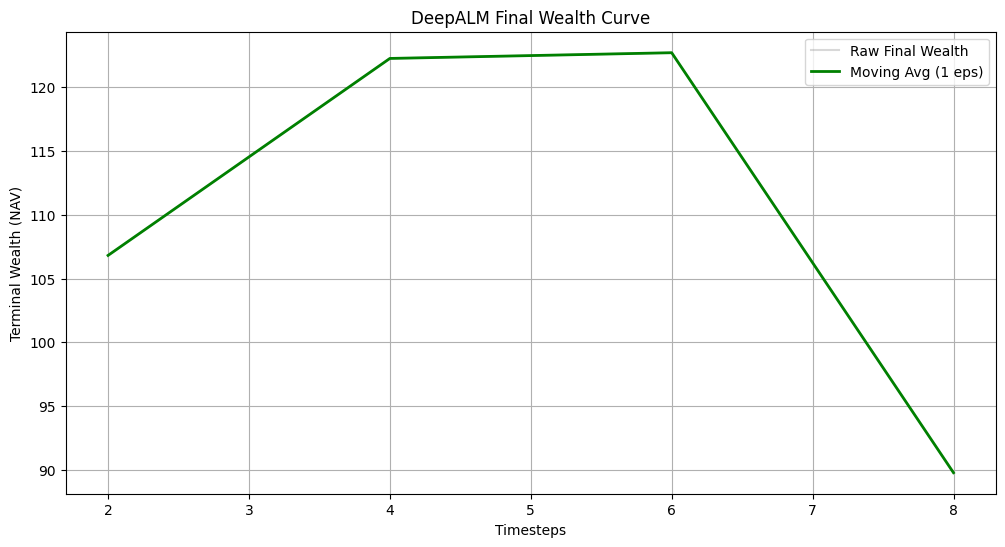

In [22]:
if TRAINING:
    plot_final_wealth(log_dir)

In [23]:
# Detailed single-episode evaluation
print("\nRunning Single Episode Deep Dive")
evaluate_sac_agent(model, markov_config, K, seed=0, verbose=True);


Running Single Episode Deep Dive
Month 1:
1M Bond Lots: None
3M Bond Lots: None
6M Bond Lots: None
12M Bond Lots: None
24M Bond Lots: None
  Current Market Yields
    1M: 1.96%
    3M: 2.54%
    6M: 2.90%
    12M: 3.13%
    24M: 3.29%
  Cash Before Action: 2000.00
  Inflows: 0.00  |  Liability Due: 59.29  |  Next Liability: 59.29
  Cash After Action: 681.01
  LCR: 11.5244  |  Utility: -0.47
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  | Bond Type       |        1M        2M        3M        4M        5M        6M        7M        8M        9M       10M       11M       12M       13M       14M       15M       16M       17M       18M       19M       20M       21M       22M       23M       24M |      Total |
  -----------------------------------------------

In [24]:
# Out-of-sample statistical evaluation
print("\n--- Running Out-Of-Sample Evaluation ---")
eval_metrics, eval_raw_results = evaluate_sac_alm(
    model=model,
    markov_config=markov_config,
    eval_episodes=100_000,
    seed_offset=10_000_000,
    verbose_first_episode=True
)


--- Running Out-Of-Sample Evaluation ---

--- Starting SAC Evaluation ---
Ep 0 | Month  1 | NAV:   704.26 | LCR: 13.01 | Step Reward: 0.00
Ep 0 | Month  2 | NAV:   711.68 | LCR:  5.23 | Step Reward: 0.00
Ep 0 | Month  3 | NAV:   704.32 | LCR:  2.29 | Step Reward: 0.00
Ep 0 | Month  4 | NAV:   206.21 | LCR:  0.08 | Step Reward: 0.00
Ep 0 | Month  5 | NAV:   -31.24 | LCR:  0.00 | Step Reward: -1.03


KeyboardInterrupt: 

In [ ]:
model.save("saved_models/sacdp.zip")
